<a href="https://colab.research.google.com/github/Yugesh-003/DL-lab/blob/master/cnn_own2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

not yet optimized

In [1]:
import kagglehub
import shutil
import os

# download
path = kagglehub.dataset_download("muniryadi/cat-vs-rabbit")

print("Original path:", path)

# move to working dir
target_path = "/content/cat_rabbit"

if not os.path.exists(target_path):
    shutil.copytree(path, target_path)

print("Dataset ready at:", target_path)

100%|██████████| 65.9M/65.9M [00:00<00:00, 85.5MB/s]

Extracting files...


Original path: /root/.cache/kagglehub/datasets/muniryadi/cat-vs-rabbit/versions/4
Dataset ready at: /content/cat_rabbit


In [14]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

IMG_SIZE = (128,128)
BATCH_SIZE = 32

train_ds = image_dataset_from_directory(
    "/content/cat_rabbit/train-cat-rabbit",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_ds = image_dataset_from_directory(
    "/content/cat_rabbit/val-cat-rabbit",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_ds = image_dataset_from_directory(
    "/content/cat_rabbit/test-images",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

class_names = train_ds.class_names
print(class_names)

Found 1600 files belonging to 2 classes.
Found 414 files belonging to 2 classes.
Found 15 files belonging to 2 classes.
['cat', 'rabbit']


In [15]:
import numpy as np

def to_numpy(ds):
    X = np.concatenate([x.numpy() for x, y in ds])
    y = np.concatenate([y.numpy() for x, y in ds])
    return X, y

X_train, y_train = to_numpy(train_ds)
X_val, y_val     = to_numpy(val_ds)
X_test, y_test   = to_numpy(test_ds)

print(X_train.shape, X_val.shape, X_test.shape)

(1600, 128, 128, 3) (414, 128, 128, 3) (15, 128, 128, 3)


In [6]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32,3,activation="relu", input_shape=(128,128,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dropout(0.3),

    layers.Dense(len(class_names),activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.5158 - loss: 52.6511 - val_accuracy: 0.4227 - val_loss: 0.7039
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.5616 - loss: 0.6860 - val_accuracy: 0.5556 - val_loss: 0.7029
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6101 - loss: 0.6486 - val_accuracy: 0.4130 - val_loss: 0.7153
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.6285 - loss: 0.6451 - val_accuracy: 0.4251 - val_loss: 0.7585
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step - accuracy: 0.6691 - loss: 0.6040 - val_accuracy: 0.4879 - val_loss: 0.7749
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.6740 - loss: 0.5587 - val_accuracy: 0.4734 - val_loss: 0.7724
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.7101 - loss: 0.5225 - val_accuracy: 0.3744 - val_loss: 0.8236
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 54s 1s/step - accuracy: 0.6924 - loss: 0.5406 - val_accuracy: 0.4106 - val_loss

In [8]:
loss, acc = model.evaluate(X_test, y_test)
print("Test accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 269ms/step - accuracy: 0.4667 - loss: 1.0486
Test accuracy: 0.46666666865348816


In [13]:
print(X_train.min(), X_train.max(), X_train.dtype)

0.0 255.0 float32


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step


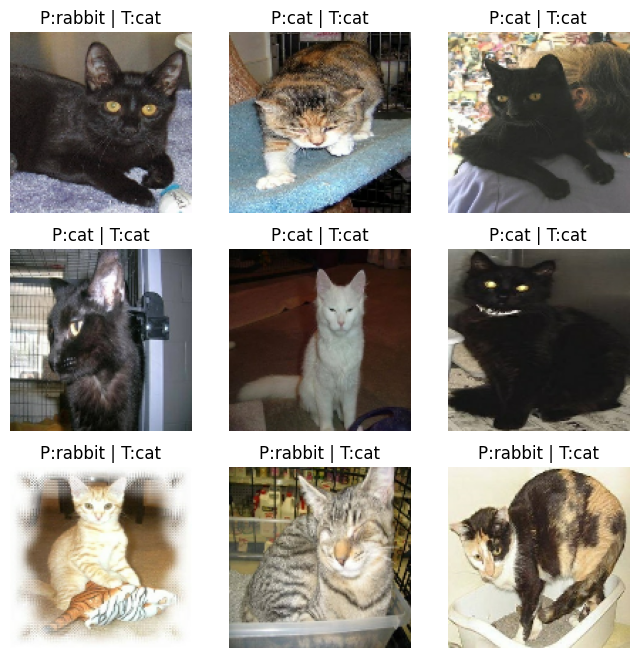

In [16]:
import matplotlib.pyplot as plt

preds = model.predict(X_test[:9])

plt.figure(figsize=(8,8))

for i in range(9):
    ax = plt.subplot(3,3,i+1)
    plt.imshow((X_test[i]).astype("uint8"))

    pred = class_names[np.argmax(preds[i])]
    true = class_names[y_test[i]]

    plt.title(f"P:{pred} | T:{true}")
    plt.axis("off")

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


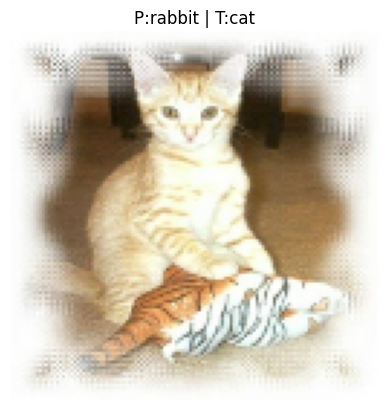

In [33]:
import matplotlib.pyplot as plt
import numpy as np

def predict_one(idx):
    img = X_test[idx]

    pred = model.predict(img[None, ...])
    pred_label = class_names[np.argmax(pred)]
    true_label = class_names[y_test[idx]]

    plt.imshow(img.astype("uint8"))
    plt.title(f"P:{pred_label} | T:{true_label}")
    plt.axis("off")
    plt.show()
predict_one(6)

IndexError: index 100 is out of bounds for axis 0 with size 15